In [1]:
import fig01, fig03
import matplotlib.pyplot as plt

# notebook defaults
plt.rcParams.update({"font.size": 12, "font.family": "Helvetica"})

In [2]:
# load + preprocess
df195 = fig01.preproc_df()

# print number of trials (single-line)
n_trials = df195["RT"].count()
trials_per_day = df195.groupby("day")["RT"].count()
trials_per_bin = df195.groupby("trial")["RT"].count()
print(
    f"n trials: {n_trials} \t n trials/day: mean={trials_per_day.mean():.1f}, std={trials_per_day.std():.1f} \t "
    f"n trials/bin: mean={trials_per_bin.mean():.1f}, std={trials_per_bin.std():.1f}"
)

n trials: 42754 	 n trials/day: mean=541.2, std=203.7 	 n trials/bin: mean=890.7, std=562.6


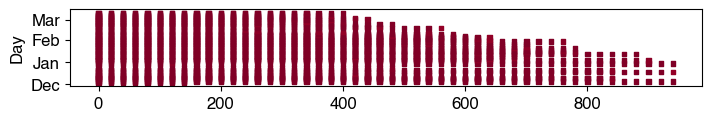

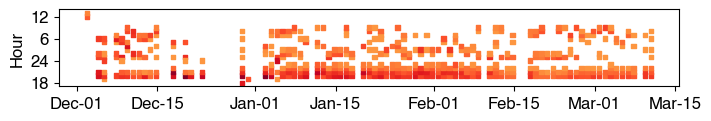

In [3]:
# fit and plot heatmaps

hm_fitby_trial = df195.groupby(["trial", "day"], as_index=False)["RT"].count()
fig, ax = plt.subplots(figsize=(7, 1.1), layout="constrained")
fig03.plot_heatmap(ax, hm_fitby_trial, fitby="trial")

hm_fitby_day = df195.groupby(["day", "hour"], as_index=False)["RT"].count()
fig, ax = plt.subplots(figsize=(7, 1.1), layout="constrained")
fig03.plot_heatmap(ax=ax, df=hm_fitby_day, fitby="day")

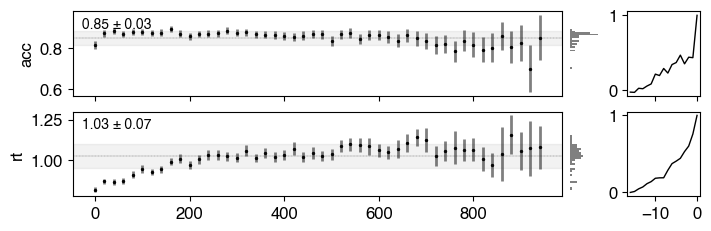

In [4]:
# fit and plot accuracy and reaction times

beh_fitby_trial = fig03.fit_beh(df=df195, fitby="trial")
beh_fitby_day = fig03.fit_beh(df=df195, fitby="day")

fig, axs = plt.subplots(
    nrows=2, ncols=3, figsize=(7, 2.2), width_ratios=[10, 0.6, 1.5], sharex="col", layout="constrained"
)
fig03.plot_estimates(axs=axs[0], df=beh_fitby_trial, fitby="trial", col="acc")
fig03.plot_estimates(axs=axs[1], df=beh_fitby_trial, fitby="trial", col="rt")

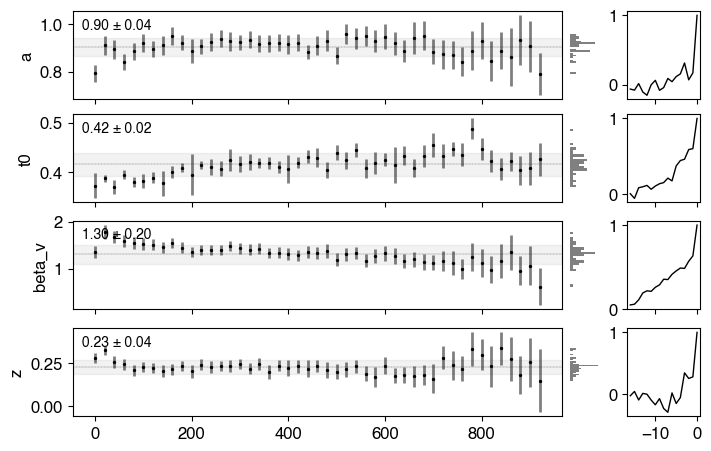

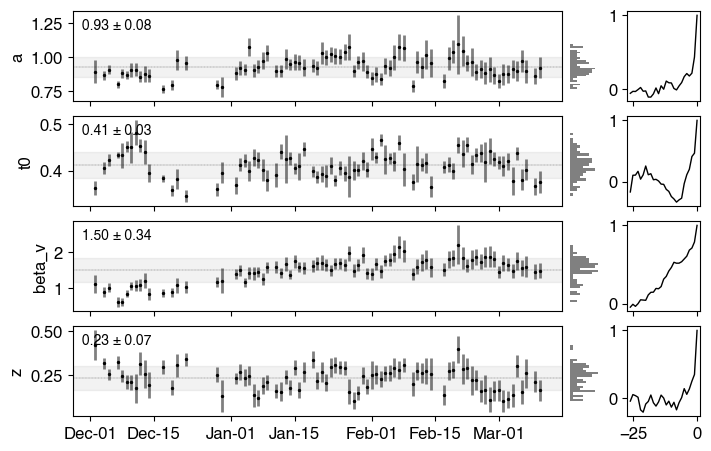

In [5]:
# fit and plot DDM parameters
ddm_fitby_trial = fig03.fit_ddm(df=df195, fitby="trial", refit=False)
ddm_fitby_day = fig03.fit_ddm(df=df195, fitby="day", refit=False)

fig, axs = plt.subplots(
    nrows=4, ncols=3, figsize=(7, 4.4), width_ratios=[10, 0.6, 1.5], sharex="col", layout="constrained"
)
fig03.plot_estimates(axs=axs[0], df=ddm_fitby_trial, fitby="trial", col="a")
fig03.plot_estimates(axs=axs[1], df=ddm_fitby_trial, fitby="trial", col="t0")
fig03.plot_estimates(axs=axs[2], df=ddm_fitby_trial, fitby="trial", col="beta_v")
fig03.plot_estimates(axs=axs[3], df=ddm_fitby_trial, fitby="trial", col="z")

fig, axs = plt.subplots(
    nrows=4, ncols=3, figsize=(7, 4.4), width_ratios=[10, 0.6, 1.5], sharex="col", layout="constrained"
)
fig03.plot_estimates(axs=axs[0], df=ddm_fitby_day, fitby="day", col="a")
fig03.plot_estimates(axs=axs[1], df=ddm_fitby_day, fitby="day", col="t0")
fig03.plot_estimates(axs=axs[2], df=ddm_fitby_day, fitby="day", col="beta_v")
fig03.plot_estimates(axs=axs[3], df=ddm_fitby_day, fitby="day", col="z")